In [266]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [267]:
df = pd.read_csv('Churn_Modelling.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [268]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [269]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler


In [270]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [271]:
df.describe().round(2)

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.0
mean,5000.50,15690940.57,650.53,38.92,5.01,76485.89,1.53,0.71,0.52,100090.24,0.2
std,2886.90,71936.19,96.65,10.49,2.89,62397.41,0.58,0.46,0.50,57510.49,0.4
min,1.00,15565701.00,350.00,18.00,0.00,0.00,1.00,0.00,0.00,11.58,0.0
25%,2500.75,15628528.25,584.00,32.00,3.00,0.00,1.00,0.00,0.00,51002.11,0.0
50%,5000.50,15690738.00,652.00,37.00,5.00,97198.54,1.00,1.00,1.00,100193.92,0.0
75%,7500.25,15753233.75,718.00,44.00,7.00,127644.24,2.00,1.00,1.00,149388.25,0.0
max,10000.00,15815690.00,850.00,92.00,10.00,250898.09,4.00,1.00,1.00,199992.48,1.0


In [272]:
new_df = pd.DataFrame(df,columns = ['Age','Tenure'])

In [273]:
new_df.head()

,Age,Tenure
0,42,2
1,41,1
2,42,8
3,39,1
4,43,2


In [274]:
new_df.isna().sum()

Age       0
Tenure    0
dtype: int64

In [275]:
scaler = MinMaxScaler()
normalizer_df = scaler.fit_transform(new_df)
normalizer_df

array([[0.32432432, 0.2       ],
       [0.31081081, 0.1       ],
       [0.32432432, 0.8       ],
       ...,
       [0.24324324, 0.7       ],
       [0.32432432, 0.3       ],
       [0.13513514, 0.4       ]])

In [276]:
scaler = StandardScaler()
normalizer_df = scaler.fit_transform(new_df)
normalizer_df

array([[ 0.29351742, -1.04175968],
       [ 0.19816383, -1.38753759],
       [ 0.29351742,  1.03290776],
       ...,
       [-0.27860412,  0.68712986],
       [ 0.29351742, -0.69598177],
       [-1.04143285, -0.35020386]])

In [277]:
import statistics

In [278]:
# Place your csv file inside this folder --> MyDrive/AI, Data Science & Analytics
data = pd.read_csv('raw_sales.csv')

In [279]:
data.head()

,datesold,postcode,price,propertyType,bedrooms
0,2007-02-07 00:00:00,2607,525000,house,4
1,2007-02-27 00:00:00,2906,290000,house,3
2,2007-03-07 00:00:00,2905,328000,house,3
3,2007-03-09 00:00:00,2905,380000,house,4
4,2007-03-21 00:00:00,2906,310000,house,3


In [280]:
type(data)

pandas.core.frame.DataFrame

In [281]:
def find_anomalies(data):
    anomalies = []

    anomalies_std = statistics.stdev(data)
    anomalies_mean = statistics.mean(data)

    anomalies_cutoff = anomalies_std * 3

    lower_limit = anomalies_mean - anomalies_cutoff
    upper_limit = anomalies_mean + anomalies_cutoff

    for outlier in data:
        if outlier > upper_limit or outlier < lower_limit:
            anomalies.append(outlier)
    return anomalies


In [282]:
data.price

0        525000
1        290000
2        328000
3        380000
4        310000
          ...  
29575    500000
29576    560000
29577    464950
29578    589000
29579    775000
Name: price, Length: 29580, dtype: int64

In [283]:
list_1 = find_anomalies(data['price'])
len(list_1)

461

In [284]:
data.shape # 461 / 29580 * 100 gives us 1.55 so it is not normally distributed

(29580, 5)

In [285]:
data.price.skew()

np.float64(4.312009366902366)

<Axes: xlabel='price', ylabel='Density'>

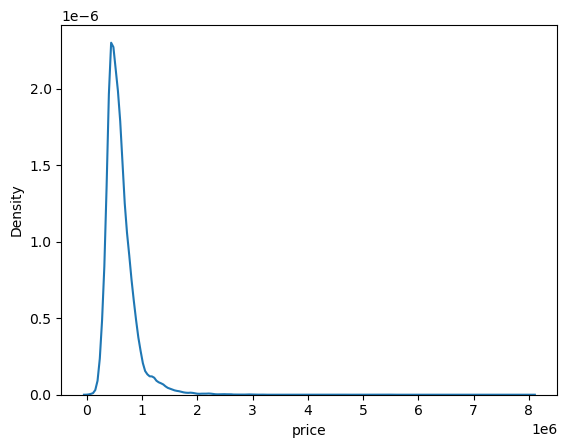

In [286]:
sns.kdeplot(data.price)

In [287]:
data['price_transformed'] = np.log(data.price)

In [288]:
data['price_transformed'].skew()

np.float64(0.4731646269984763)

In [289]:
list_2 = find_anomalies(data.price_transformed)
len(list_2)

266

<Axes: xlabel='price_transformed', ylabel='Density'>

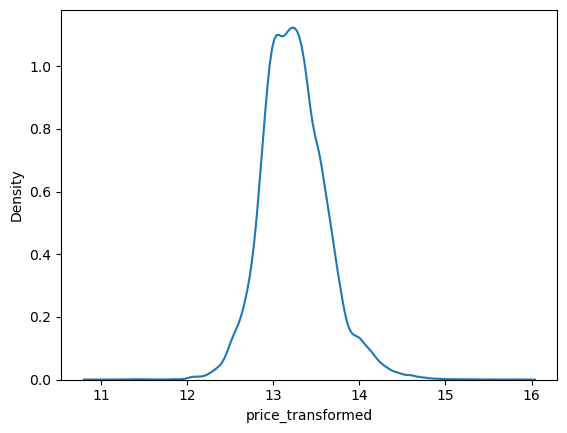

In [290]:
sns.kdeplot(data.price_transformed)

In [291]:
data['data_tranformation_double'] = np.log(data.price_transformed)

In [292]:
list3 = find_anomalies(data.data_tranformation_double)


In [293]:
len(list3)

251

<Axes: xlabel='data_tranformation_double', ylabel='Density'>

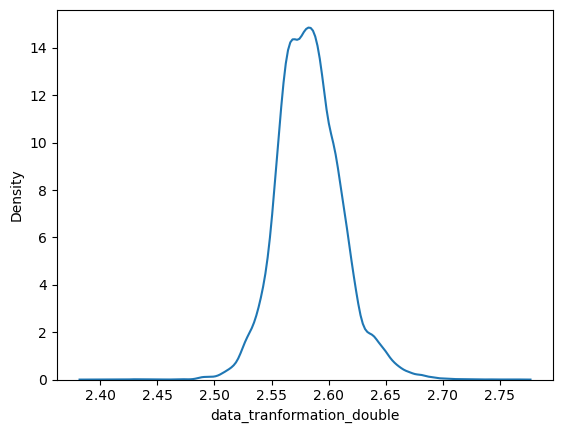

In [294]:
sns.kdeplot(data.data_tranformation_double)

<Axes: >

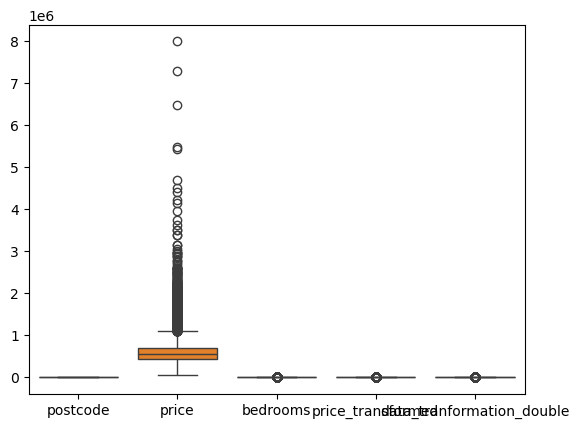

In [295]:
sns.boxplot(data=data)

In [296]:
data.describe()

,postcode,price,bedrooms,price_transformed,data_tranformation_double
count,29580.000000,2.958000e+04,29580.000000,29580.000000,29580.000000
mean,2730.249730,6.097363e+05,3.250169,13.244695,2.583199
std,146.717292,2.817079e+05,0.951275,0.375214,0.028183
min,2600.000000,5.650000e+04,0.000000,10.941996,2.392608
25%,2607.000000,4.400000e+05,3.000000,12.994530,2.564529
50%,2615.000000,5.500000e+05,3.000000,13.217674,2.581555
75%,2905.000000,7.050000e+05,4.000000,13.465953,2.600165
max,2914.000000,8.000000e+06,5.000000,15.894952,2.766002


In [297]:
list1 = [43,54,56,67,78,45,34,62,34,12,23,55,61,78,75,90]
len(list1)

16

In [298]:
max(list1)

90

In [299]:
min(list1)

12

In [300]:
statistics.mean(list1)

54.1875

In [301]:
sorted(list1)

[12, 23, 34, 34, 43, 45, 54, 55, 56, 61, 62, 67, 75, 78, 78, 90]

In [302]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [303]:
df_new = df[['Geography' , 'Gender' ,'Exited']]

In [304]:
df_new.head()

,Geography,Gender,Exited
0,France,Female,1
1,Spain,Female,0
2,France,Female,1
3,France,Female,0
4,Spain,Female,0


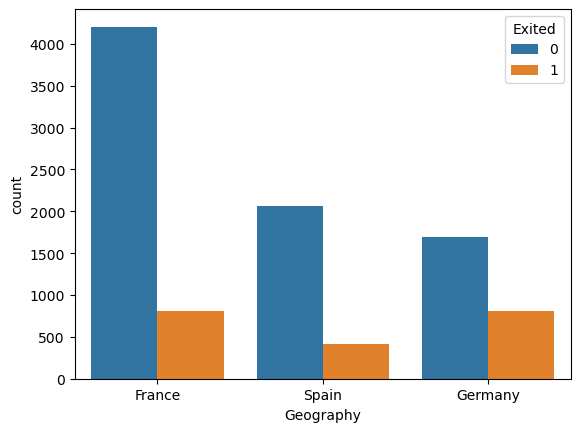

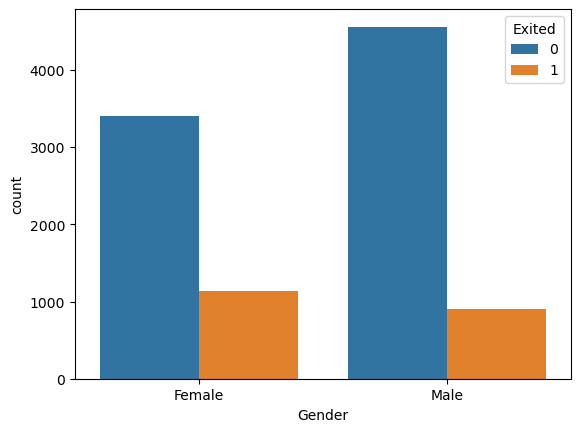

In [305]:
for i ,predictor in enumerate(df_new.drop(columns = ['Exited'])):
    plt.figure()
    sns.countplot(data=df_new,x= predictor , hue='Exited')


<Axes: xlabel='Gender', ylabel='Count'>

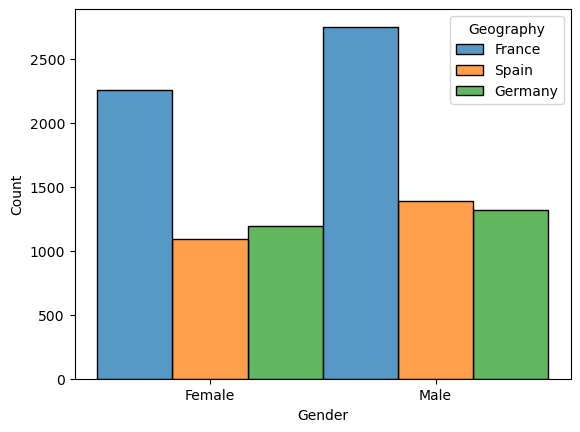

In [306]:
# Bivariate Analysis


sns.histplot(x = 'Gender', hue='Geography', data= df_new , stat= "count" , multiple= "dodge")

In [307]:
df_new_target = df_new.loc[df_new["Exited"] == 1]

<Axes: xlabel='Gender', ylabel='Count'>

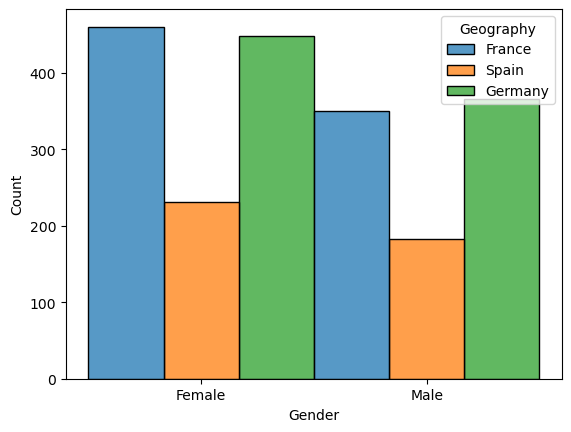

In [308]:
sns.histplot(x = 'Gender', hue='Geography', data= df_new_target , stat= "count" , multiple= "dodge")

Correlation : it ranges from -1 to +1

- +1 --> Positive Correlation
- -1 --> Negative Correlation
- 0 --> No Correlation

In [309]:
df.select_dtypes(include='number').corr()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
RowNumber,1.000000,0.004202,0.005840,0.000783,-0.006495,-0.009067,0.007246,0.000599,0.012044,-0.005988,-0.016571
CustomerId,0.004202,1.000000,0.005308,0.009497,-0.014883,-0.012419,0.016972,-0.014025,0.001665,0.015271,-0.006248
CreditScore,0.005840,0.005308,1.000000,-0.003965,0.000842,0.006268,0.012238,-0.005458,0.025651,-0.001384,-0.027094
Age,0.000783,0.009497,-0.003965,1.000000,-0.009997,0.028308,-0.030680,-0.011721,0.085472,-0.007201,0.285323
Tenure,-0.006495,-0.014883,0.000842,-0.009997,1.000000,-0.012254,0.013444,0.022583,-0.028362,0.007784,-0.014001
Balance,-0.009067,-0.012419,0.006268,0.028308,-0.012254,1.000000,-0.304180,-0.014858,-0.010084,0.012797,0.118533
NumOfProducts,0.007246,0.016972,0.012238,-0.030680,0.013444,-0.304180,1.000000,0.003183,0.009612,0.014204,-0.047820
HasCrCard,0.000599,-0.014025,-0.005458,-0.011721,0.022583,-0.014858,0.003183,1.000000,-0.011866,-0.009933,-0.007138
IsActiveMember,0.012044,0.001665,0.025651,0.085472,-0.028362,-0.010084,0.009612,-0.011866,1.000000,-0.011421,-0.156128
EstimatedSalary,-0.005988,0.015271,-0.001384,-0.007201,0.007784,0.012797,0.014204,-0.009933,-0.011421,1.000000,0.012097


In [310]:
df

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


<Axes: >

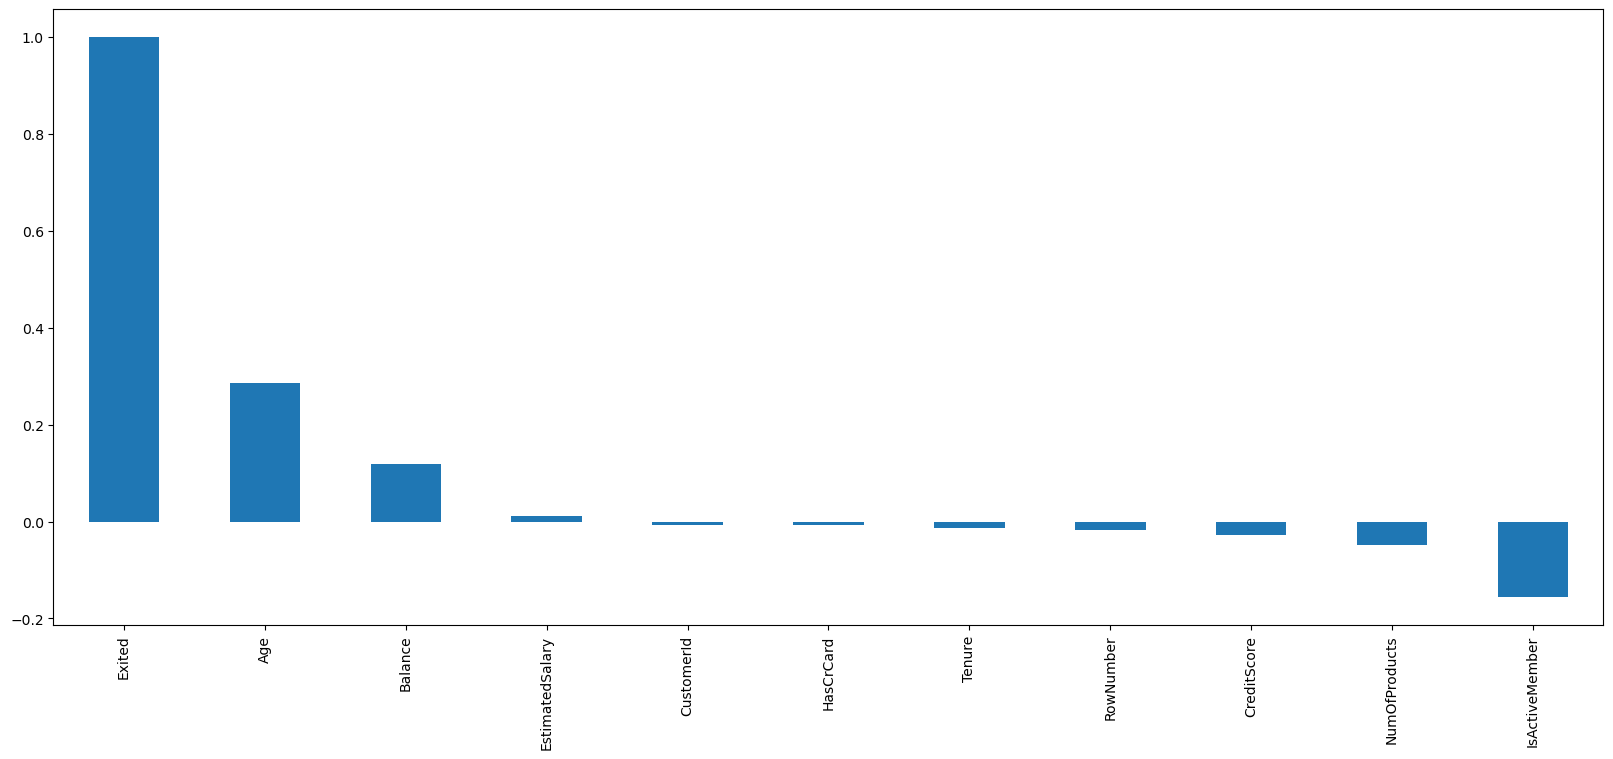

In [311]:
plt.figure(figsize=(20,8))
df.select_dtypes(include='number').corr()["Exited"].sort_values(ascending=False).plot(kind="bar")

<Axes: >

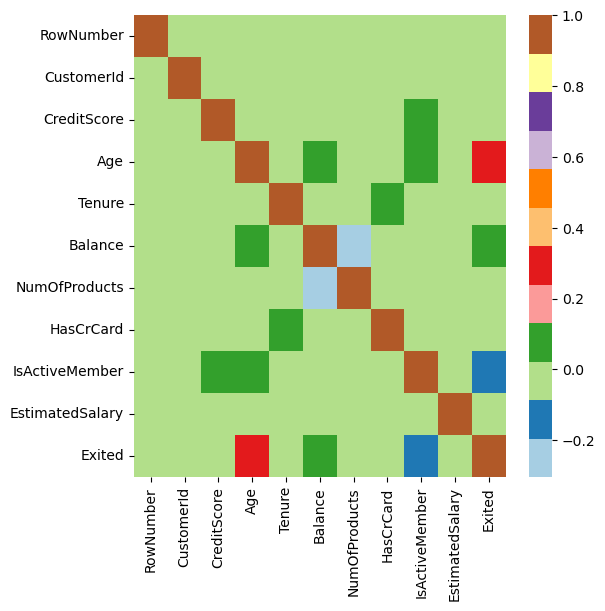

In [312]:
plt.figure(figsize=(6,6))
sns.heatmap(df.select_dtypes(include='number').corr() , cmap='Paired')

In [313]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


<Axes: xlabel='Age'>

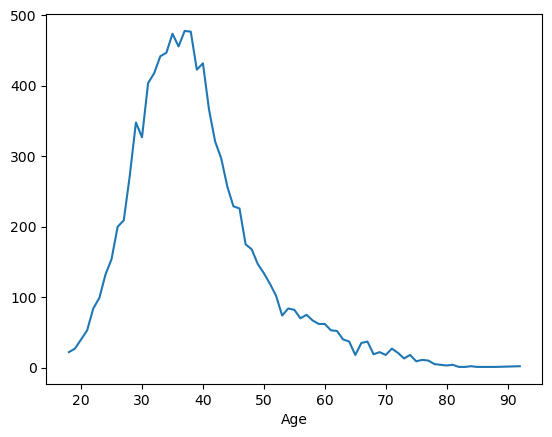

In [314]:
df['Age'].value_counts().sort_index(ascending=True).plot()

<Axes: xlabel='Age'>

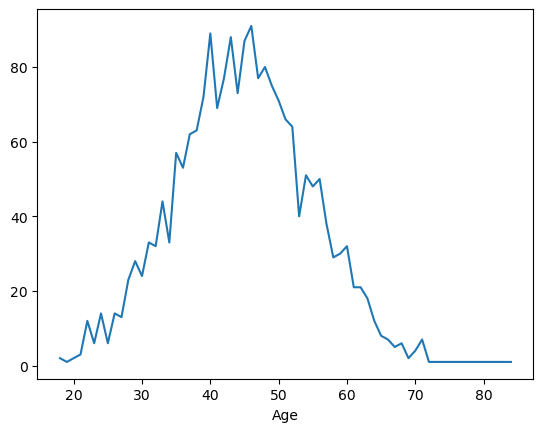

In [315]:
df_1 = df.loc[df['Exited'] == 1]
df_1['Age'].value_counts().sort_index(ascending=True).plot()

In [316]:
df_1.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
5,6,15574012,Chu,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1
7,8,15656148,Obinna,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1
16,17,15737452,Romeo,653,Germany,Male,58,1,132602.88,1,1,0,5097.67,1


/var/folders/qw/_nk9z1hd74q9vjp80k85r5l80000gn/T/ipykernel_79201/2090043207.py:1: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  tot = sns.kdeplot(df.Age[(df['Exited'] == 0)],color="red", shade = True)
/var/folders/qw/_nk9z1hd74q9vjp80k85r5l80000gn/T/ipykernel_79201/2090043207.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  tot = sns.kdeplot(df.Age[(df['Exited'] == 1)],color="Blue", shade = True)


Text(0.5, 1.0, 'Age by churn')

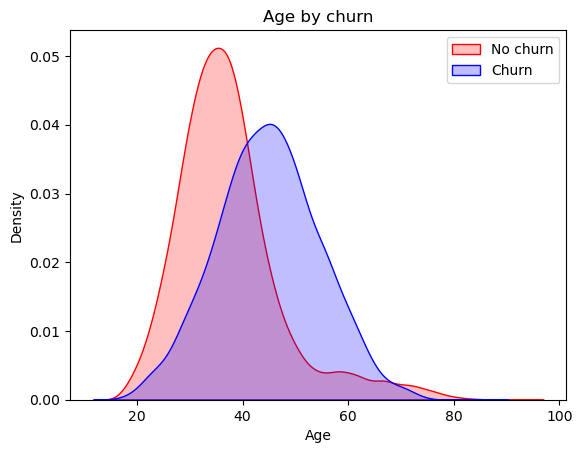

In [317]:
tot = sns.kdeplot(df.Age[(df['Exited'] == 0)],color="red", shade = True)
tot = sns.kdeplot(df.Age[(df['Exited'] == 1)],color="Blue", shade = True)
tot.legend(["No churn" , "Churn" ], loc= 'upper right')
tot.set_ylabel('Density')
tot.set_xlabel('Age')
tot.set_title('Age by churn')


/var/folders/qw/_nk9z1hd74q9vjp80k85r5l80000gn/T/ipykernel_79201/1873088014.py:1: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  tot = sns.kdeplot(df.Tenure[(df['Exited'] == 0)],color="red", shade = True)
/var/folders/qw/_nk9z1hd74q9vjp80k85r5l80000gn/T/ipykernel_79201/1873088014.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  tot = sns.kdeplot(df.Tenure[(df['Exited'] == 1)],color="Blue", shade = True)


Text(0.5, 1.0, 'Tenure by churn')

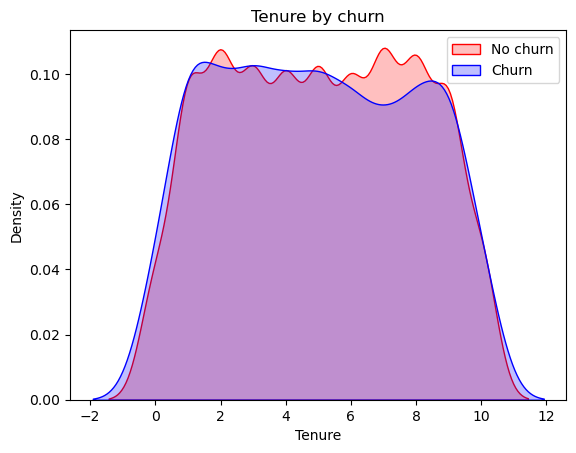

In [318]:
tot = sns.kdeplot(df.Tenure[(df['Exited'] == 0)],color="red", shade = True)
tot = sns.kdeplot(df.Tenure[(df['Exited'] == 1)],color="Blue", shade = True)
tot.legend(["No churn" , "Churn" ], loc= 'upper right')
tot.set_ylabel('Density')
tot.set_xlabel('Tenure')
tot.set_title('Tenure by churn')


/var/folders/qw/_nk9z1hd74q9vjp80k85r5l80000gn/T/ipykernel_79201/202332554.py:1: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  tot = sns.kdeplot(df.Balance[(df['Exited'] == 0)],color="red", shade = True)
/var/folders/qw/_nk9z1hd74q9vjp80k85r5l80000gn/T/ipykernel_79201/202332554.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  tot = sns.kdeplot(df.Balance[(df['Exited'] == 1)],color="Blue", shade = True)


Text(0.5, 1.0, 'Balance by churn')

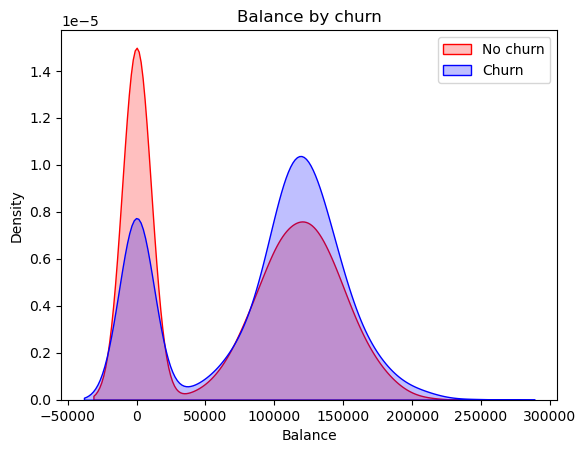

In [319]:
tot = sns.kdeplot(df.Balance[(df['Exited'] == 0)],color="red", shade = True)
tot = sns.kdeplot(df.Balance[(df['Exited'] == 1)],color="Blue", shade = True)
tot.legend(["No churn" , "Churn" ], loc= 'upper right')
tot.set_ylabel('Density')
tot.set_xlabel('Balance')
tot.set_title('Balance by churn')


Feature Binning

In [320]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [321]:
from sklearn import preprocessing

In [322]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [323]:
df.drop(columns=['CustomerId','Surname','RowNumber'],axis=1, inplace=True)

In [324]:
df.describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [325]:
labels = ['0-20','21-40','41-60','Above 61']
bins = [0,20,40,60,100]
df['age_bins'] = pd.cut(df.Age,bins,labels  = labels,include_lowest=True)
df

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,age_bins
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,41-60
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,41-60
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,41-60
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,21-40
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,41-60
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5,0.00,2,1,0,96270.64,0,21-40
9996,516,France,Male,35,10,57369.61,1,1,1,101699.77,0,21-40
9997,709,France,Female,36,7,0.00,1,0,1,42085.58,1,21-40
9998,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1,41-60


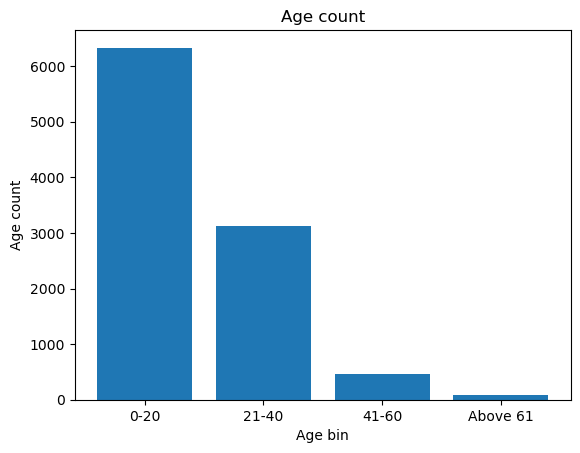

In [326]:
plt.bar(labels,df.age_bins.value_counts())
plt.title('Age count')
plt.xlabel('Age bin')
plt.ylabel('Age count')
plt.show()

In [327]:
def add_labels(x,y):
    for i in range(len(x)):
        plt.text(i,y[i],y[i])

/var/folders/qw/_nk9z1hd74q9vjp80k85r5l80000gn/T/ipykernel_79201/2111627238.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(i,y[i],y[i])


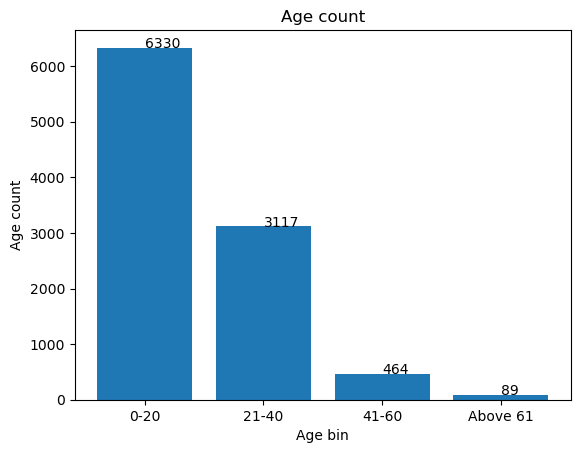

In [328]:
plt.bar(labels,df.age_bins.value_counts())
add_labels(labels,df.age_bins.value_counts())
plt.title('Age count')
plt.xlabel('Age bin')
plt.ylabel('Age count')
plt.show()

Feature Encoding

In [329]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,age_bins
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,41-60
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,41-60
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,41-60
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,21-40
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,41-60


label Encoding

In [330]:
le = preprocessing.LabelEncoder()
df['Gender_Label'] = le.fit_transform(df.Gender.values)

In [331]:
df

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,age_bins,Gender_Label
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,41-60,0
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,41-60,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,41-60,0
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,21-40,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,41-60,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5,0.00,2,1,0,96270.64,0,21-40,1
9996,516,France,Male,35,10,57369.61,1,1,1,101699.77,0,21-40,1
9997,709,France,Female,36,7,0.00,1,0,1,42085.58,1,21-40,0
9998,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1,41-60,1


In [332]:
df['Gender_Label'].value_counts()

Gender_Label
1    5457
0    4543
Name: count, dtype: int64

One Hot Encoding

In [333]:
one_hot = pd.get_dummies(df['Geography'])
one_hot

,France,Germany,Spain
0,True,False,False
1,False,False,True
2,True,False,False
3,True,False,False
4,False,False,True
...,...,...,...
9995,True,False,False
9996,True,False,False
9997,True,False,False
9998,False,True,False


In [334]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,age_bins,Gender_Label
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,41-60,0
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,41-60,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,41-60,0
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,21-40,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,41-60,0


In [335]:
df_dummies = pd.get_dummies(df)
df_dummies.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Gender_Label,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male,age_bins_0-20,age_bins_21-40,age_bins_41-60,age_bins_Above 61
0,619,42,2,0.00,1,1,1,101348.88,1,0,True,False,False,True,False,False,False,True,False
1,608,41,1,83807.86,1,0,1,112542.58,0,0,False,False,True,True,False,False,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,0,True,False,False,True,False,False,False,True,False
3,699,39,1,0.00,2,0,0,93826.63,0,0,True,False,False,True,False,False,True,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,0,False,False,True,True,False,False,False,True,False


Dummy encoding

In [336]:
df_dummies = pd.get_dummies(df,drop_first=True)
df_dummies.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Gender_Label,Geography_Germany,Geography_Spain,Gender_Male,age_bins_21-40,age_bins_41-60,age_bins_Above 61
0,619,42,2,0.00,1,1,1,101348.88,1,0,False,False,False,False,True,False
1,608,41,1,83807.86,1,0,1,112542.58,0,0,False,True,False,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,0,False,False,False,False,True,False
3,699,39,1,0.00,2,0,0,93826.63,0,0,False,False,False,True,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,0,False,True,False,False,True,False


In [337]:
from category_encoders import TargetEncoder

In [338]:
df

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,age_bins,Gender_Label
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,41-60,0
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,41-60,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,41-60,0
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,21-40,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,41-60,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5,0.00,2,1,0,96270.64,0,21-40,1
9996,516,France,Male,35,10,57369.61,1,1,1,101699.77,0,21-40,1
9997,709,France,Female,36,7,0.00,1,0,1,42085.58,1,21-40,0
9998,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1,41-60,1


In [339]:
encoder = TargetEncoder()

In [340]:
df['Gender Encoder'] = encoder.fit_transform(df['Gender'],df['Exited'])

In [341]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,age_bins,Gender_Label,Gender Encoder
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,41-60,0,0.250715
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,41-60,0,0.250715
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,41-60,0,0.250715
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,21-40,0,0.250715
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,41-60,0,0.250715


# benefits of TE : 
 - Target encoding is simple and quick encoding method that doesn't add any dimensionality of the dataset ,therefore, it may be used as a good  first try technique

# Limitation:
- It is dependent on the target distribution which means  target encoding requires  careful validation  as it can be prone to overfitting.

### Hash Encoding

In [342]:
from category_encoders import HashingEncoder

In [343]:
x = df.Gender
y = df.Exited

In [344]:
ce_hash = HashingEncoder(cols = ['Gender'])
ce_hash.fit_transform(x,y)

,col_0,col_1,col_2,col_3,col_4,col_5,col_6,col_7
0,0,0,0,0,0,0,0,1
1,0,0,0,0,0,0,0,1
2,0,0,0,0,0,0,0,1
3,0,0,0,0,0,0,0,1
4,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...
9995,0,0,0,0,0,1,0,0
9996,0,0,0,0,0,1,0,0
9997,0,0,0,0,0,0,0,1
9998,0,0,0,0,0,1,0,0


In [345]:
x = df.Geography

In [346]:
ce_hash = HashingEncoder(cols = ['Geography'])
ce_hash.fit_transform(x,y)

,col_0,col_1,col_2,col_3,col_4,col_5,col_6,col_7
0,0,1,0,0,0,0,0,0
1,0,0,0,1,0,0,0,0
2,0,1,0,0,0,0,0,0
3,0,1,0,0,0,0,0,0
4,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...
9995,0,1,0,0,0,0,0,0
9996,0,1,0,0,0,0,0,0
9997,0,1,0,0,0,0,0,0
9998,0,0,0,0,0,0,0,1
